### ***727723EUAI109 : Sanjay M***

### ***Practice : 1***

In [6]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [7]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target']).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape after preprocessing: {X_scaled.shape}")

Shape after preprocessing: (569, 30)


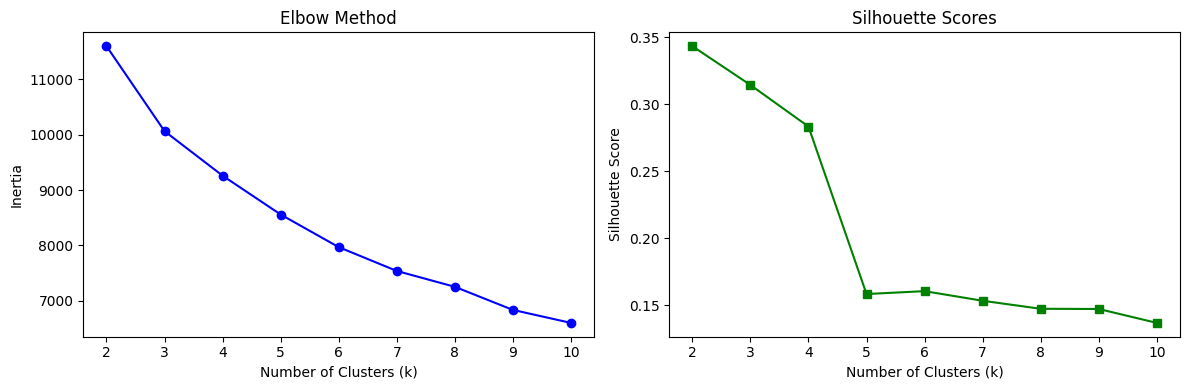

Best k by Silhouette: 2 (score: 0.3434)


In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

# Silhouette Plot
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'gs-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')

plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k by Silhouette: {best_k} (score: {max(sil_scores):.4f})")

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f"KMeans trained with k={best_k}")
print(f"Inertia: {kmeans.inertia_:.2f}")

KMeans trained with k=2
Inertia: 11595.53


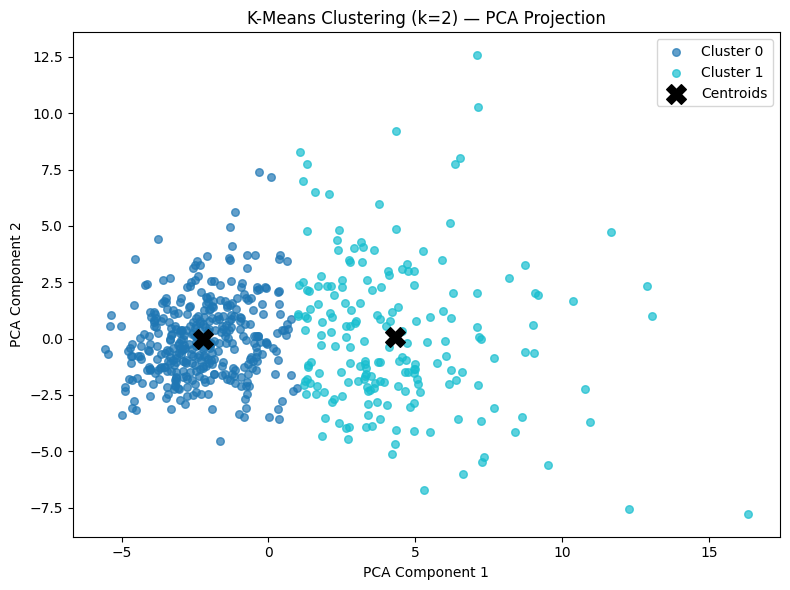

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, best_k))

for i in range(best_k):
    pts = X_pca[cluster_labels == i]
    plt.scatter(pts[:, 0], pts[:, 1], s=30, color=colors[i], label=f'Cluster {i}', alpha=0.7)

# Plot centroids projected to PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, c='black', marker='X', label='Centroids', zorder=5)

plt.title(f'K-Means Clustering (k={best_k}) — PCA Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({'k': list(k_range), 'Inertia': inertias, 'Silhouette Score': sil_scores})
print(results.to_string(index=False))

drops = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
elbow_k = list(k_range)[drops.index(max(drops)) + 1]

print(f"\nElbow Method suggests k = {elbow_k}")
print(f"Silhouette Method suggests k = {best_k}")
print(f"\nBest k selected: {best_k}")
print(f"Final Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print("\nInterpretation: A silhouette score closer to 1.0 indicates well-separated, compact clusters.")

 k      Inertia  Silhouette Score
 2 11595.526607          0.343382
 3 10061.797818          0.314384
 4  9258.989105          0.283305
 5  8558.660667          0.158210
 6  7970.263835          0.160367
 7  7540.318697          0.153186
 8  7254.326193          0.147195
 9  6837.628936          0.147040
10  6603.404402          0.136656

Elbow Method suggests k = 3
Silhouette Method suggests k = 2

Best k selected: 2
Final Silhouette Score: 0.3434

Interpretation: A silhouette score closer to 1.0 indicates well-separated, compact clusters.
